# 📘 MACHINE LEARNING TOÀN TẬP — Notebook học tập theo GeeksforGeeks

Notebook này được biên soạn bám sát toàn bộ nội dung của **GeeksforGeeks Machine Learning Tutorial**:
`https://www.geeksforgeeks.org/machine-learning/machine-learning/`

Bao gồm đầy đủ **7 Module** chính:

| Module | Nội dung |
|---|---|
| 0 | Machine Learning là gì? Các loại ML |
| 1 | ML Pipeline: Data Preprocessing, EDA, Model Evaluation |
| 2 | Supervised Learning: Linear/Logistic Regression, Decision Tree, SVM, KNN, Naive Bayes, Random Forest, Ensemble Learning |
| 3 | Unsupervised Learning: Clustering, Dimensionality Reduction, Association Rule Mining |
| 4 | Reinforcement Learning: MDP, Bellman Equation, Value Iteration, Q-Learning, SARSA |
| 5 | Semi-Supervised & Self-Supervised Learning |
| 6 | Forecasting Models: ARIMA, SARIMA, Exponential Smoothing |
| 7 | Deployment: Flask, FastAPI, Streamlit, Gradio, MLOps |

> **Cách dùng:** Chạy lần lượt từ trên xuống dưới. Mỗi phần có mục lý thuyết ngắn gọn (tiếng Việt) + code minh họa chạy được bằng `scikit-learn`, `numpy`, `pandas`, `matplotlib`.
> Một số phần (Module 6 - Forecasting) cần cài thêm thư viện `statsmodels`. Một số phần (Association Rule) cần `mlxtend`. Lệnh cài đặt được ghi ngay tại mục tương ứng.

---

## ⚙️ 0. Cài đặt & Import thư viện cần thiết

In [1]:
# Cài các thư viện cần thiết (bỏ comment nếu chưa có)
# !pip install numpy pandas matplotlib seaborn scikit-learn statsmodels mlxtend

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)

print("Đã import xong các thư viện cơ bản!")


Đã import xong các thư viện cơ bản!


---
# 🎯 Module 0: Machine Learning là gì?

**Machine Learning (ML)** là một nhánh của Trí tuệ nhân tạo (AI), tập trung xây dựng các mô hình/thuật toán giúp máy tính **học từ dữ liệu** mà không cần lập trình tường minh cho từng tác vụ. Nói cách khác, ML giúp hệ thống "suy nghĩ" và học hỏi giống con người thông qua dữ liệu.

## Ba loại hình học chính

1. **Supervised Learning (Học có giám sát):** huấn luyện mô hình trên dữ liệu đã gán nhãn để dự đoán/phân loại dữ liệu mới.
2. **Unsupervised Learning (Học không giám sát):** tìm ra cấu trúc/mẫu ẩn trong dữ liệu không có nhãn (clustering, giảm chiều dữ liệu...).
3. **Reinforcement Learning (Học tăng cường):** agent học thông qua thử-sai (trial and error) để tối đa hóa phần thưởng (reward), phù hợp cho bài toán ra quyết định tuần tự.

### Hai loại bổ sung (ngày càng quan trọng trong Deep Learning)

- **Self-Supervised Learning:** một dạng của unsupervised learning nhưng tự tạo nhãn từ chính dữ liệu, không cần gán nhãn thủ công (nền tảng của các mô hình lớn như BERT, GPT...).
- **Semi-Supervised Learning:** kết hợp một lượng nhỏ dữ liệu có nhãn với lượng lớn dữ liệu không nhãn — hữu ích khi việc gán nhãn tốn kém/mất thời gian.

## Quy trình (Pipeline) tổng quát của một dự án ML

```
Thu thập dữ liệu → Tiền xử lý dữ liệu (Data Preprocessing)
   → Phân tích khám phá dữ liệu (EDA)
   → Feature Engineering / Feature Selection
   → Huấn luyện mô hình (Training)
   → Đánh giá mô hình (Evaluation)
   → Tinh chỉnh siêu tham số (Hyperparameter Tuning)
   → Triển khai mô hình (Deployment)
   → Giám sát & bảo trì (Monitoring / MLOps)
```

Notebook này sẽ đi qua từng bước theo đúng cấu trúc 7 Module của GeeksforGeeks.

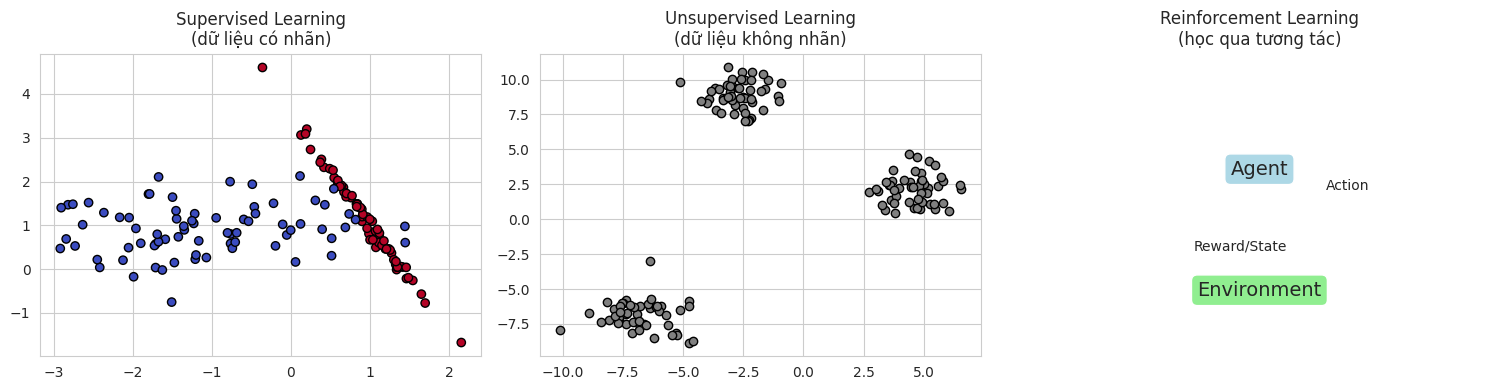

In [2]:
# Minh họa trực quan: 3 loại ML dùng chung 1 tập dữ liệu 2D
from sklearn.datasets import make_blobs, make_classification, make_regression

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Supervised - Classification
X_c, y_c = make_classification(n_samples=150, n_features=2, n_redundant=0,
                                n_informative=2, n_clusters_per_class=1, random_state=42)
axes[0].scatter(X_c[:, 0], X_c[:, 1], c=y_c, cmap="coolwarm", edgecolor="k")
axes[0].set_title("Supervised Learning\n(dữ liệu có nhãn)")

# Unsupervised - Clustering
X_u, _ = make_blobs(n_samples=150, centers=3, random_state=42)
axes[1].scatter(X_u[:, 0], X_u[:, 1], c="gray", edgecolor="k")
axes[1].set_title("Unsupervised Learning\n(dữ liệu không nhãn)")

# Reinforcement - minh họa agent/environment bằng sơ đồ text
axes[2].axis("off")
axes[2].text(0.5, 0.6, "Agent", ha="center", fontsize=14, bbox=dict(boxstyle="round", fc="lightblue"))
axes[2].text(0.5, 0.2, "Environment", ha="center", fontsize=14, bbox=dict(boxstyle="round", fc="lightgreen"))
axes[2].annotate("Action", xy=(0.65, 0.35), xytext=(0.65, 0.55), arrowprops=dict(arrowstyle="->"))
axes[2].annotate("Reward/State", xy=(0.35, 0.55), xytext=(0.35, 0.35), arrowprops=dict(arrowstyle="->"))
axes[2].set_title("Reinforcement Learning\n(học qua tương tác)")

plt.tight_layout()
plt.show()


---
# 🧩 Module 1: Machine Learning Pipeline

Module này bao gồm 3 phần: **Data Preprocessing**, **Exploratory Data Analysis (EDA)**, **Model Evaluation**.

## 1.1 Data Preprocessing (Tiền xử lý dữ liệu)

Dữ liệu thực tế thường bị thiếu, nhiễu, không đồng nhất. Các bước tiền xử lý phổ biến:

- **Data Cleaning**: xử lý giá trị thiếu (missing values), giá trị trùng lặp (duplicates), ngoại lai (outliers).
- **Feature Scaling**: đưa các đặc trưng về cùng thang đo (Normalization, Standardization).
- **Feature Extraction**: trích xuất đặc trưng mới từ dữ liệu thô (ví dụ: trích đặc trưng từ văn bản, ảnh).
- **Feature Engineering**: tạo ra các đặc trưng mới có ý nghĩa hơn từ đặc trưng gốc.
- **Feature Selection**: chọn ra tập con đặc trưng quan trọng nhất, loại bỏ đặc trưng dư thừa/nhiễu.

In [3]:
# --- Data Cleaning: xử lý missing values, duplicates ---
df = pd.DataFrame({
    "Tuoi": [25, np.nan, 35, 40, 25, np.nan],
    "LuongUSD": [1000, 1500, np.nan, 2000, 1000, 1500],
    "GioiTinh": ["Nam", "Nu", "Nam", "Nu", "Nam", "Nu"]
})
print("Dữ liệu gốc:")
print(df)
print("\nSố giá trị thiếu mỗi cột:\n", df.isnull().sum())

# Loại bỏ dòng trùng lặp
df_clean = df.drop_duplicates()

# Điền missing value bằng trung bình (numeric) 
df_clean["Tuoi"] = df_clean["Tuoi"].fillna(df_clean["Tuoi"].mean())
df_clean["LuongUSD"] = df_clean["LuongUSD"].fillna(df_clean["LuongUSD"].median())

print("\nSau khi làm sạch:")
print(df_clean)


Dữ liệu gốc:
   Tuoi  LuongUSD GioiTinh
0  25.0    1000.0      Nam
1   NaN    1500.0       Nu
2  35.0       NaN      Nam
3  40.0    2000.0       Nu
4  25.0    1000.0      Nam
5   NaN    1500.0       Nu

Số giá trị thiếu mỗi cột:
 Tuoi        2
LuongUSD    1
GioiTinh    0
dtype: int64

Sau khi làm sạch:
        Tuoi  LuongUSD GioiTinh
0  25.000000    1000.0      Nam
1  33.333333    1500.0       Nu
2  35.000000    1500.0      Nam
3  40.000000    2000.0       Nu


In [4]:
# --- Feature Scaling: Normalization vs Standardization ---
from sklearn.preprocessing import MinMaxScaler, StandardScaler

data = pd.DataFrame({"A": [10, 20, 30, 40, 50], "B": [1, 5, 3, 8, 2]})

minmax = MinMaxScaler()
data_norm = pd.DataFrame(minmax.fit_transform(data), columns=data.columns)

std = StandardScaler()
data_std = pd.DataFrame(std.fit_transform(data), columns=data.columns)

print("Gốc:\n", data)
print("\nNormalization (Min-Max về [0,1]):\n", data_norm)
print("\nStandardization (mean=0, std=1):\n", data_std.round(2))


Gốc:
     A  B
0  10  1
1  20  5
2  30  3
3  40  8
4  50  2

Normalization (Min-Max về [0,1]):
       A         B
0  0.00  0.000000
1  0.25  0.571429
2  0.50  0.285714
3  0.75  1.000000
4  1.00  0.142857

Standardization (mean=0, std=1):
       A     B
0 -1.41 -1.13
1 -0.71  0.48
2  0.00 -0.32
3  0.71  1.69
4  1.41 -0.73


In [5]:
# --- Feature Extraction (ví dụ: trích xuất từ text bằng TF-IDF) ---
from sklearn.feature_extraction.text import TfidfVectorizer

corpus = [
    "machine learning rất thú vị",
    "học sâu là một nhánh của machine learning",
    "xử lý ngôn ngữ tự nhiên dùng machine learning"
]
tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(corpus)
print("Từ vựng:", tfidf.get_feature_names_out())
print("Ma trận TF-IDF:\n", X_tfidf.toarray().round(2))


Từ vựng: ['của' 'dùng' 'học' 'learning' 'là' 'lý' 'machine' 'một' 'ngôn' 'ngữ'
 'nhiên' 'nhánh' 'rất' 'sâu' 'thú' 'tự' 'vị' 'xử']
Ma trận TF-IDF:
 [[0.   0.   0.   0.31 0.   0.   0.31 0.   0.   0.   0.   0.   0.52 0.
  0.52 0.   0.52 0.  ]
 [0.39 0.   0.39 0.23 0.39 0.   0.23 0.39 0.   0.   0.   0.39 0.   0.39
  0.   0.   0.   0.  ]
 [0.   0.36 0.   0.21 0.   0.36 0.21 0.   0.36 0.36 0.36 0.   0.   0.
  0.   0.36 0.   0.36]]


In [6]:
# --- Feature Engineering: tạo đặc trưng mới ---
df_fe = pd.DataFrame({
    "ngay_sinh": pd.to_datetime(["2000-01-15", "1995-06-20", "1988-11-02"]),
    "thu_nhap": [1000, 2500, 4000],
    "chi_tieu": [800, 1200, 3000]
})
# Tạo đặc trưng "tuổi" từ ngày sinh
df_fe["tuoi"] = 2026 - df_fe["ngay_sinh"].dt.year
# Tạo đặc trưng tỉ lệ tiết kiệm
df_fe["ty_le_tiet_kiem"] = (df_fe["thu_nhap"] - df_fe["chi_tieu"]) / df_fe["thu_nhap"]
print(df_fe)


   ngay_sinh  thu_nhap  chi_tieu  tuoi  ty_le_tiet_kiem
0 2000-01-15      1000       800    26             0.20
1 1995-06-20      2500      1200    31             0.52
2 1988-11-02      4000      3000    38             0.25


In [7]:
# --- Feature Selection: chọn đặc trưng quan trọng bằng SelectKBest ---
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.datasets import load_iris

iris = load_iris()
X, y = iris.data, iris.target

selector = SelectKBest(score_func=f_classif, k=2)
X_selected = selector.fit_transform(X, y)

selected_idx = selector.get_support(indices=True)
print("Các đặc trưng gốc:", iris.feature_names)
print("2 đặc trưng được chọn:", [iris.feature_names[i] for i in selected_idx])
print("Điểm số (F-score) từng đặc trưng:", selector.scores_.round(2))


Các đặc trưng gốc: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
2 đặc trưng được chọn: ['petal length (cm)', 'petal width (cm)']
Điểm số (F-score) từng đặc trưng: [ 119.26   49.16 1180.16  960.01]


## 1.2 Exploratory Data Analysis (EDA)

EDA là bước **khám phá dữ liệu** trước khi mô hình hóa: xem phân phối, tương quan, giá trị ngoại lai... nhằm hiểu rõ bản chất dữ liệu và định hướng tiền xử lý/lựa chọn mô hình phù hợp.

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  

Phân bố lớp:
 species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


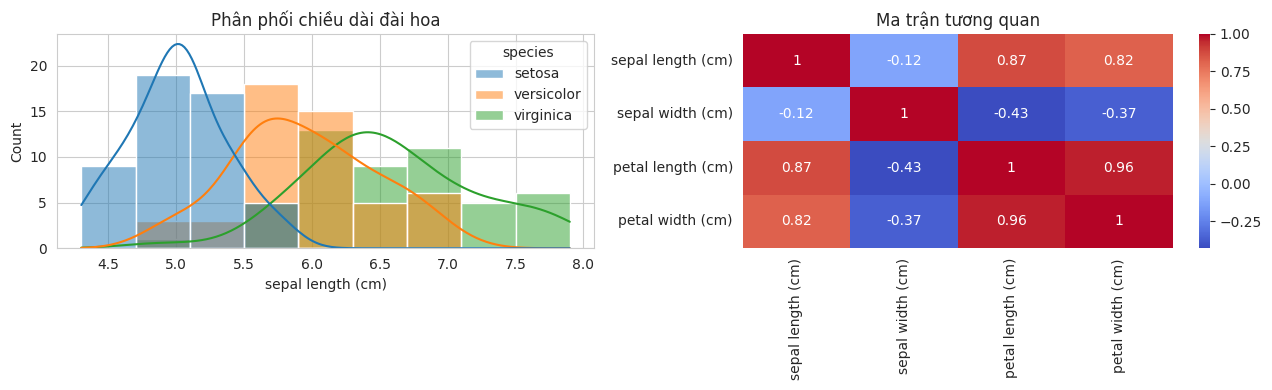

In [8]:
# --- EDA cơ bản với dataset Iris ---
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df["species"] = pd.Categorical.from_codes(iris.target, iris.target_names)

print(iris_df.describe())
print("\nPhân bố lớp:\n", iris_df["species"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(data=iris_df, x="sepal length (cm)", hue="species", kde=True, ax=axes[0])
axes[0].set_title("Phân phối chiều dài đài hoa")

sns.heatmap(iris_df.drop(columns="species").corr(), annot=True, cmap="coolwarm", ax=axes[1])
axes[1].set_title("Ma trận tương quan")
plt.tight_layout()
plt.show()


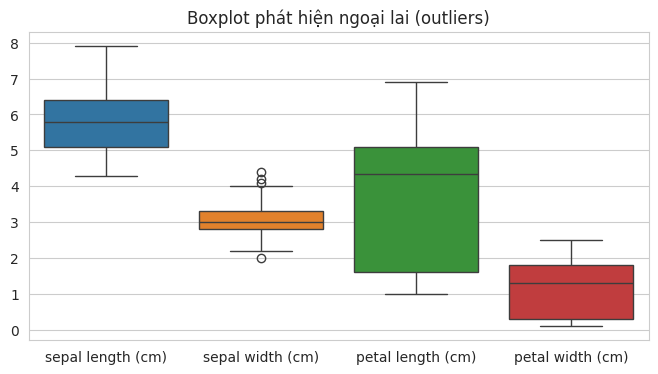

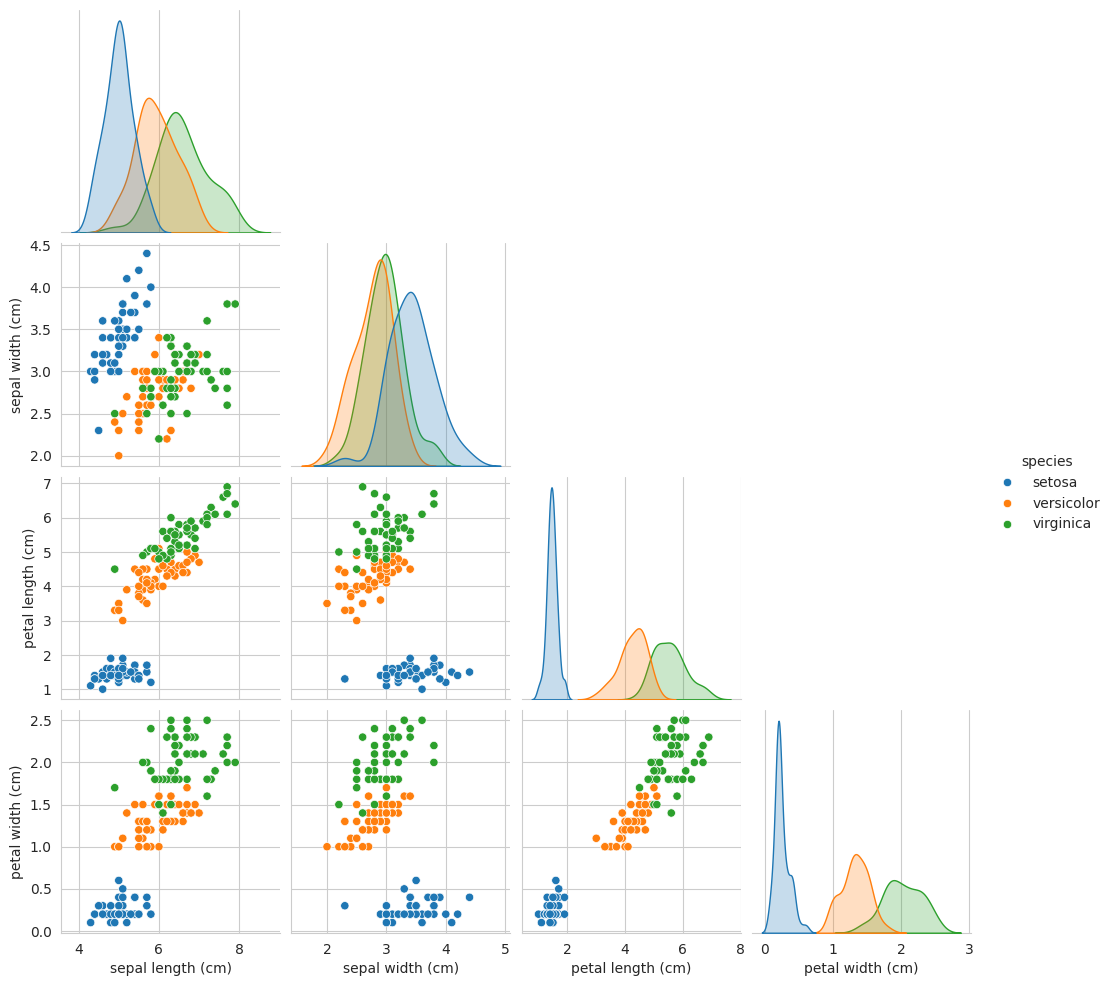

In [9]:
# --- EDA: Boxplot phát hiện outlier + pairplot quan hệ giữa các biến ---
plt.figure(figsize=(8, 4))
sns.boxplot(data=iris_df.drop(columns="species"))
plt.title("Boxplot phát hiện ngoại lai (outliers)")
plt.show()

sns.pairplot(iris_df, hue="species", corner=True)
plt.show()


## 1.3 Model Evaluation (Đánh giá mô hình)

Sau khi huấn luyện, cần đánh giá mô hình bằng các chỉ số phù hợp:

- **Regularization (L1/L2)**: kỹ thuật giảm overfitting bằng cách phạt các hệ số lớn.
- **Confusion Matrix**: bảng thể hiện số dự đoán đúng/sai theo từng lớp.
- **Precision, Recall, F1-score**: đo độ chính xác/độ phủ, đặc biệt quan trọng với dữ liệu mất cân bằng.
- **AUC-ROC Curve**: đo khả năng phân biệt lớp của mô hình phân loại.
- **Cross-validation**: chia dữ liệu thành nhiều fold để đánh giá mô hình ổn định hơn.
- **Hyperparameter Tuning**: tìm bộ siêu tham số tối ưu (GridSearchCV, RandomizedSearchCV).
- **Bias-Variance Tradeoff / Overfitting-Underfitting**: hiểu và cân bằng độ phức tạp mô hình.

Confusion Matrix:
 [[26  0]
 [ 0 19]]
Precision: 1.000
Recall:    1.000
F1-score:  1.000


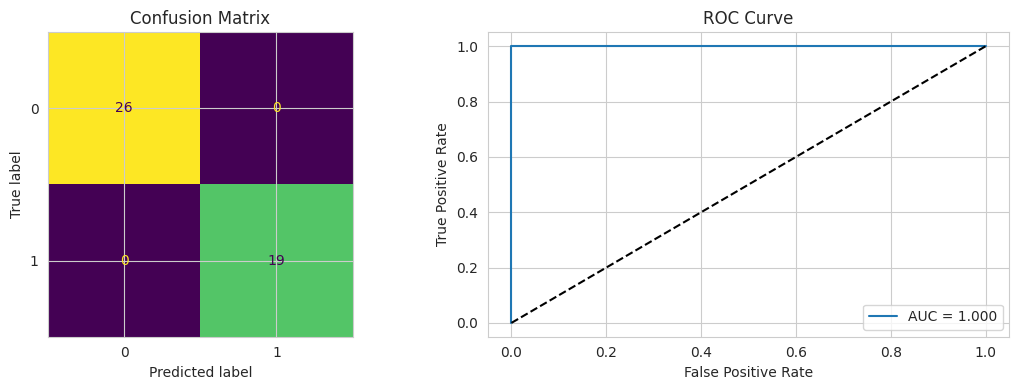

In [10]:
# --- Confusion Matrix, Precision/Recall/F1, ROC-AUC ---
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, classification_report,
                              precision_score, recall_score, f1_score,
                              roc_curve, auc, ConfusionMatrixDisplay)

# Bài toán nhị phân: lớp 0 (setosa) vs "không phải setosa"
y_bin = (iris.target == 0).astype(int)
X_train, X_test, y_train, y_test = train_test_split(iris.data, y_bin, test_size=0.3, random_state=42)

clf = LogisticRegression(max_iter=200).fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred):.3f}")
print(f"F1-score:  {f1_score(y_test, y_pred):.3f}")

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay(cm).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix")
axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
axes[1].plot([0, 1], [0, 1], "k--")
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve"); axes[1].legend()
plt.tight_layout(); plt.show()


In [11]:
# --- Cross-validation & Hyperparameter Tuning (GridSearchCV) ---
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.svm import SVC

# Cross-validation 5-fold
scores = cross_val_score(SVC(kernel="rbf"), iris.data, iris.target, cv=5)
print("Điểm accuracy từng fold:", scores.round(3))
print(f"Trung bình: {scores.mean():.3f} ± {scores.std():.3f}")

# Grid Search để tìm siêu tham số tốt nhất
param_grid = {"C": [0.1, 1, 10], "gamma": ["scale", 0.01, 0.1]}
grid = GridSearchCV(SVC(kernel="rbf"), param_grid, cv=5)
grid.fit(iris.data, iris.target)
print("\nBộ tham số tốt nhất:", grid.best_params_)
print(f"Accuracy tốt nhất: {grid.best_score_:.3f}")


Điểm accuracy từng fold: [0.967 0.967 0.967 0.933 1.   ]
Trung bình: 0.967 ± 0.021

Bộ tham số tốt nhất: {'C': 1, 'gamma': 0.1}
Accuracy tốt nhất: 0.980


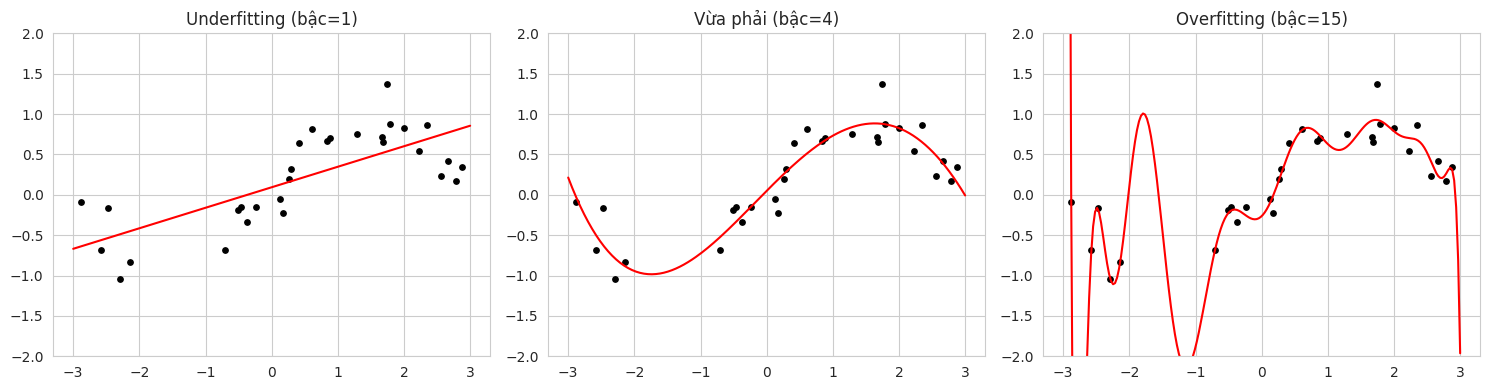

Số hệ số ≈0 của Lasso (L1 giúp feature selection): 8 / 11
Số hệ số ≈0 của Ridge (L2 chỉ giảm độ lớn, không triệt tiêu): 3 / 11


In [12]:
# --- Regularization (L1 - Lasso vs L2 - Ridge) & Bias-Variance / Overfitting minh họa ---
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

np.random.seed(0)
X_reg = np.sort(np.random.rand(30, 1) * 6 - 3, axis=0)
y_reg = np.sin(X_reg).ravel() + np.random.normal(0, 0.2, X_reg.shape[0])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
degrees = [1, 4, 15]
titles = ["Underfitting (bậc=1)", "Vừa phải (bậc=4)", "Overfitting (bậc=15)"]

for ax, deg, title in zip(axes, degrees, titles):
    model = make_pipeline(PolynomialFeatures(deg), LinearRegression())
    model.fit(X_reg, y_reg)
    X_plot = np.linspace(-3, 3, 200).reshape(-1, 1)
    ax.scatter(X_reg, y_reg, color="black", s=15)
    ax.plot(X_plot, model.predict(X_plot), color="red")
    ax.set_title(title)
    ax.set_ylim(-2, 2)
plt.tight_layout(); plt.show()

# So sánh Ridge (L2) và Lasso (L1) trên dữ liệu nhiều chiều nhiễu
poly = PolynomialFeatures(10)
X_poly = poly.fit_transform(X_reg)
ridge = Ridge(alpha=1.0).fit(X_poly, y_reg)
lasso = Lasso(alpha=0.01).fit(X_poly, y_reg)
print("Số hệ số ≈0 của Lasso (L1 giúp feature selection):", np.sum(np.abs(lasso.coef_) < 1e-3), "/", len(lasso.coef_))
print("Số hệ số ≈0 của Ridge (L2 chỉ giảm độ lớn, không triệt tiêu):", np.sum(np.abs(ridge.coef_) < 1e-3), "/", len(ridge.coef_))


---
# 🎓 Module 2: Supervised Learning (Học có giám sát)

Gồm 2 nhóm bài toán chính:
- **Classification**: dự đoán nhãn rời rạc (categories).
- **Regression**: dự đoán giá trị liên tục.

Ta sẽ đi qua các thuật toán: Linear Regression, Logistic Regression, Decision Tree, SVM, KNN, Naive Bayes, Random Forest, và Ensemble Learning.

## 2.1 Linear Regression (Hồi quy tuyến tính)

Tìm đường thẳng (hoặc siêu phẳng) khớp tốt nhất với dữ liệu để dự đoán giá trị số. Mô hình học tham số bằng cách tối thiểu hóa hàm mất mát **MSE (Mean Squared Error)** thông qua **Gradient Descent**.

- **Multiple Linear Regression**: mở rộng cho nhiều biến đầu vào cùng lúc.

Hệ số (slope): 2.842, Hệ số chặn (intercept): 4.237
MSE: 0.800, R2: 0.778


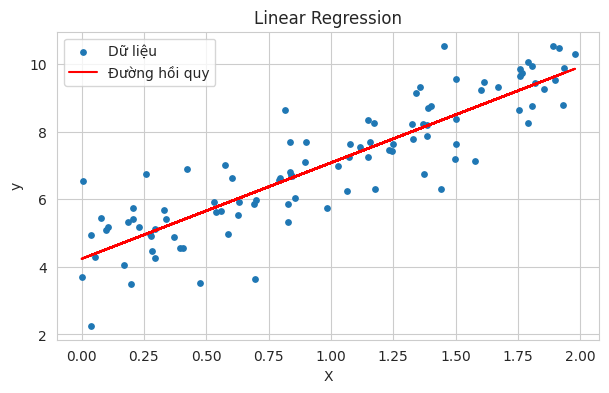

In [13]:
# --- Linear Regression + trực quan hóa Gradient Descent ---
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(1)
X_lin = 2 * np.random.rand(100, 1)
y_lin = 4 + 3 * X_lin.ravel() + np.random.randn(100)

lr = LinearRegression().fit(X_lin, y_lin)
y_pred_lin = lr.predict(X_lin)

print(f"Hệ số (slope): {lr.coef_[0]:.3f}, Hệ số chặn (intercept): {lr.intercept_:.3f}")
print(f"MSE: {mean_squared_error(y_lin, y_pred_lin):.3f}, R2: {r2_score(y_lin, y_pred_lin):.3f}")

plt.scatter(X_lin, y_lin, s=15, label="Dữ liệu")
plt.plot(X_lin, y_pred_lin, color="red", label="Đường hồi quy")
plt.xlabel("X"); plt.ylabel("y"); plt.legend(); plt.title("Linear Regression")
plt.show()


Theta học được (từ scratch): [4.232 2.847]


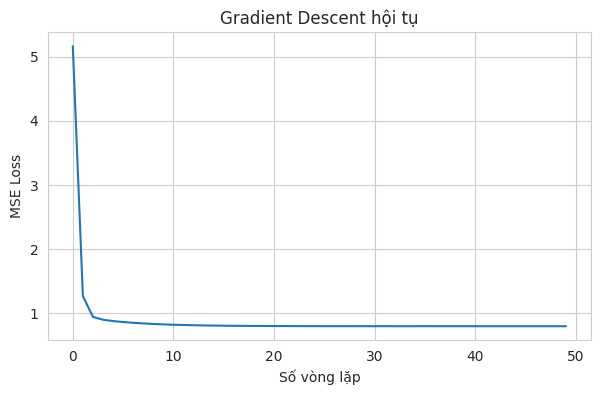

In [14]:
# --- Gradient Descent cài đặt từ đầu (từ scratch) cho Linear Regression ---
def gradient_descent(X, y, lr_rate=0.1, n_iters=100):
    m = len(y)
    X_b = np.c_[np.ones((m, 1)), X]  # thêm cột bias
    theta = np.random.randn(2, 1)
    history = []
    for i in range(n_iters):
        gradients = (2/m) * X_b.T.dot(X_b.dot(theta) - y.reshape(-1, 1))
        theta -= lr_rate * gradients
        history.append(np.mean((X_b.dot(theta).ravel() - y) ** 2))
    return theta, history

theta, loss_history = gradient_descent(X_lin, y_lin, lr_rate=0.3, n_iters=50)
print("Theta học được (từ scratch):", theta.ravel().round(3))

plt.plot(loss_history)
plt.xlabel("Số vòng lặp"); plt.ylabel("MSE Loss")
plt.title("Gradient Descent hội tụ")
plt.show()


In [15]:
# --- Multiple Linear Regression (dùng dataset Diabetes có sẵn trong sklearn) ---
from sklearn.datasets import load_diabetes

housing = load_diabetes()
X_house, y_house = housing.data, housing.target
Xh_train, Xh_test, yh_train, yh_test = train_test_split(X_house, y_house, test_size=0.2, random_state=42)

mlr = LinearRegression().fit(Xh_train, yh_train)
yh_pred = mlr.predict(Xh_test)
print(f"R2 trên tập test: {r2_score(yh_test, yh_pred):.3f}")
print("Top 3 đặc trưng ảnh hưởng mạnh nhất (theo |hệ số|):")
coef_df = pd.Series(mlr.coef_, index=housing.feature_names).sort_values(key=abs, ascending=False)
print(coef_df.head(3))


R2 trên tập test: 0.453
Top 3 đặc trưng ảnh hưởng mạnh nhất (theo |hệ số|):
s1    -931.488846
s5     736.198859
bmi    542.428759
dtype: float64


## 2.2 Logistic Regression (Hồi quy Logistic)

Dùng cho bài toán phân loại nhị phân (yes/no, spam/not spam). Dùng hàm **sigmoid** để ánh xạ đầu ra về khoảng (0,1) biểu diễn xác suất, và tối ưu bằng **hàm mất mát Log-loss (Cross-Entropy)** thay vì MSE.

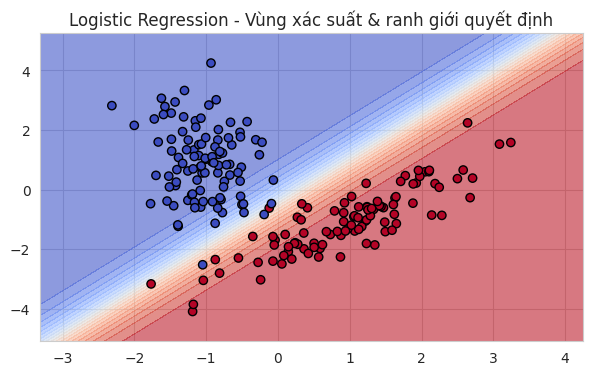

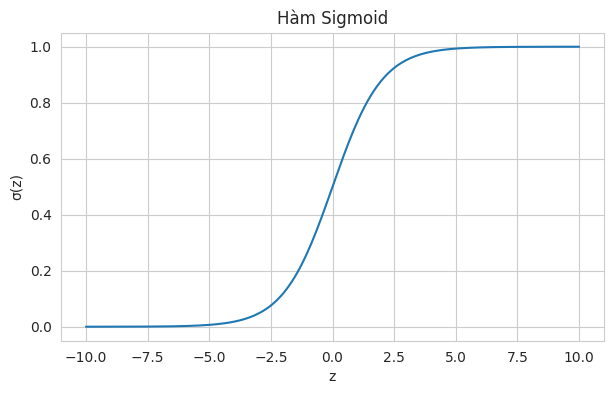

In [16]:
# --- Logistic Regression trên bài toán nhị phân ---
from sklearn.datasets import make_classification

X_log, y_log = make_classification(n_samples=200, n_features=2, n_redundant=0,
                                    n_informative=2, n_clusters_per_class=1, random_state=7)
log_reg = LogisticRegression().fit(X_log, y_log)

xx, yy = np.meshgrid(np.linspace(X_log[:,0].min()-1, X_log[:,0].max()+1, 200),
                      np.linspace(X_log[:,1].min()-1, X_log[:,1].max()+1, 200))
Z = log_reg.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

plt.contourf(xx, yy, Z, levels=20, cmap="coolwarm", alpha=0.6)
plt.scatter(X_log[:,0], X_log[:,1], c=y_log, cmap="coolwarm", edgecolor="k")
plt.title("Logistic Regression - Vùng xác suất & ranh giới quyết định")
plt.show()

# Minh họa hàm sigmoid và cost function (log-loss)
z = np.linspace(-10, 10, 200)
sigmoid = 1 / (1 + np.exp(-z))
plt.plot(z, sigmoid)
plt.title("Hàm Sigmoid"); plt.xlabel("z"); plt.ylabel("σ(z)")
plt.show()


## 2.3 Decision Tree (Cây quyết định)

Mô hình dự đoán bằng cách đặt liên tiếp các câu hỏi dạng "nếu-thì" (giống flowchart), chia dữ liệu dựa trên tiêu chí như **Gini Impurity** hoặc **Entropy/Information Gain**. Dễ hiểu, dễ trực quan hóa, nhưng dễ overfitting nếu không giới hạn độ sâu.

Có 2 loại: **Decision Tree Classification** và **Decision Tree Regression**.

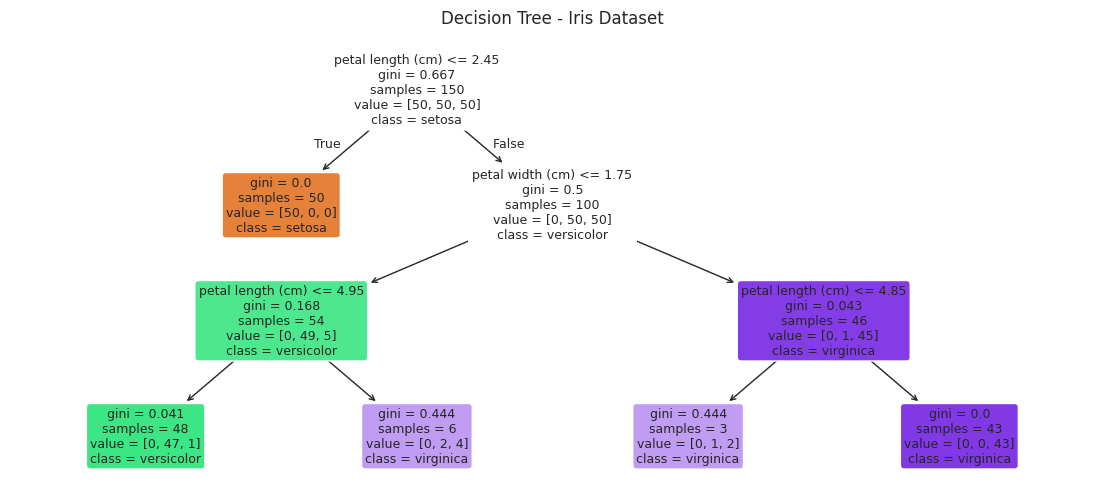

Độ chính xác (train): 0.973


In [17]:
# --- Decision Tree Classification + trực quan hóa cây ---
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree

dt_clf = DecisionTreeClassifier(max_depth=3, criterion="gini", random_state=42)
dt_clf.fit(iris.data, iris.target)

plt.figure(figsize=(14, 6))
plot_tree(dt_clf, feature_names=iris.feature_names, class_names=iris.target_names,
          filled=True, rounded=True, fontsize=9)
plt.title("Decision Tree - Iris Dataset")
plt.show()

print(f"Độ chính xác (train): {dt_clf.score(iris.data, iris.target):.3f}")


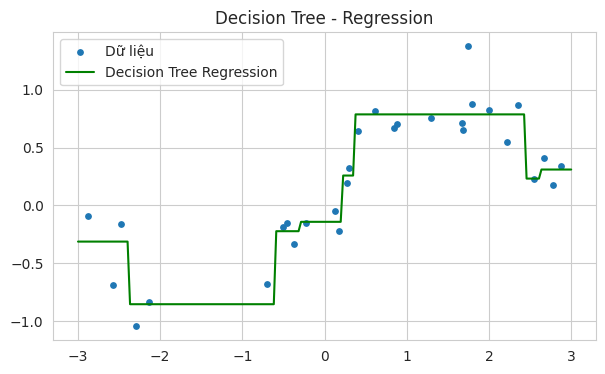

In [18]:
# --- Decision Tree Regression ---
dt_reg = DecisionTreeRegressor(max_depth=3, random_state=42).fit(X_reg, y_reg)
X_plot = np.linspace(-3, 3, 200).reshape(-1, 1)
plt.scatter(X_reg, y_reg, s=15, label="Dữ liệu")
plt.plot(X_plot, dt_reg.predict(X_plot), color="green", label="Decision Tree Regression")
plt.legend(); plt.title("Decision Tree - Regression"); plt.show()


## 2.4 Support Vector Machine (SVM)

SVM tìm **siêu phẳng (hyperplane)** tách các lớp sao cho **margin** (khoảng cách từ siêu phẳng tới các điểm gần nhất - support vectors) là lớn nhất. Với dữ liệu không tách tuyến tính được, SVM dùng **kernel trick** (RBF, polynomial...) để ánh xạ sang không gian nhiều chiều hơn.

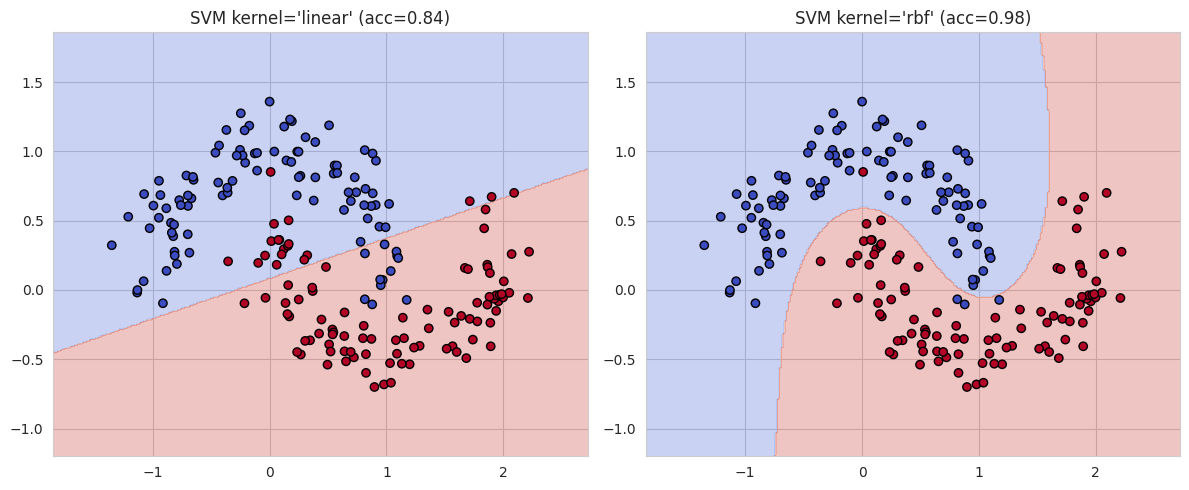

In [19]:
# --- SVM tuyến tính vs SVM kernel RBF (non-linear) ---
from sklearn.svm import SVC
from sklearn.datasets import make_moons

X_moon, y_moon = make_moons(n_samples=200, noise=0.15, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, kernel in zip(axes, ["linear", "rbf"]):
    svm = SVC(kernel=kernel, C=1.0).fit(X_moon, y_moon)
    xx, yy = np.meshgrid(np.linspace(X_moon[:,0].min()-.5, X_moon[:,0].max()+.5, 300),
                          np.linspace(X_moon[:,1].min()-.5, X_moon[:,1].max()+.5, 300))
    Z = svm.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    ax.scatter(X_moon[:,0], X_moon[:,1], c=y_moon, cmap="coolwarm", edgecolor="k")
    ax.set_title(f"SVM kernel='{kernel}' (acc={svm.score(X_moon,y_moon):.2f})")
plt.tight_layout(); plt.show()


In [20]:
# --- SVM Hyperparameter Tuning với GridSearchCV ---
param_grid_svm = {"C": [0.1, 1, 10, 100], "gamma": [0.01, 0.1, 1, "scale"]}
grid_svm = GridSearchCV(SVC(kernel="rbf"), param_grid_svm, cv=5)
grid_svm.fit(X_moon, y_moon)
print("Best params:", grid_svm.best_params_, " | Best CV acc:", round(grid_svm.best_score_, 3))


Best params: {'C': 10, 'gamma': 1}  | Best CV acc: 0.985


## 2.5 k-Nearest Neighbors (k-NN)

Thuật toán "lazy learning": dự đoán nhãn của một điểm dựa trên **k điểm gần nhất** trong tập huấn luyện (theo khoảng cách Euclidean...). Đơn giản, dựa hoàn toàn vào độ tương đồng, không cần "huấn luyện" mô hình tường minh.

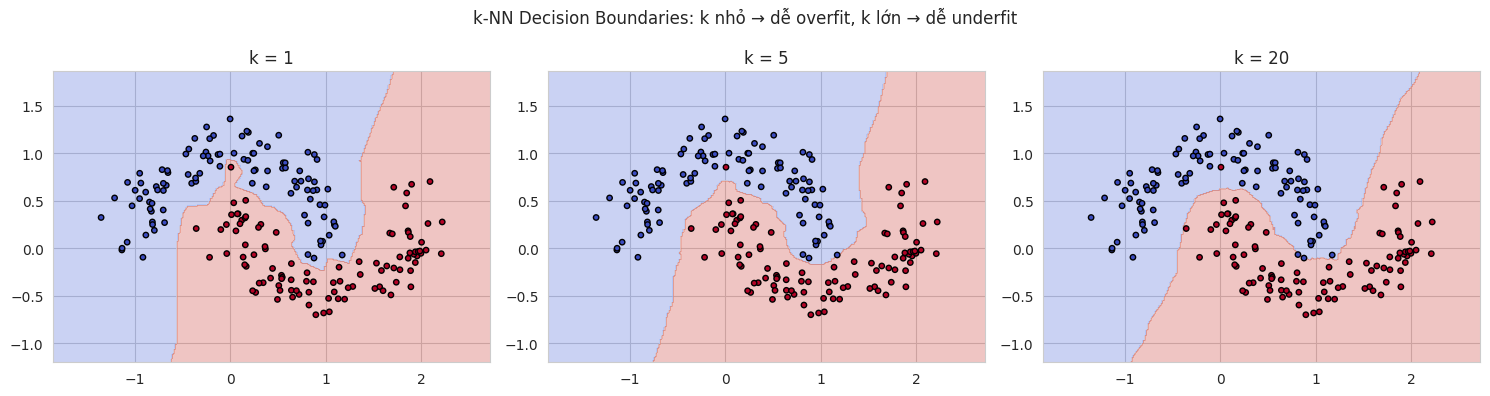

In [21]:
# --- KNN + Decision Boundaries theo các giá trị k khác nhau ---
from sklearn.neighbors import KNeighborsClassifier

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, k in zip(axes, [1, 5, 20]):
    knn = KNeighborsClassifier(n_neighbors=k).fit(X_moon, y_moon)
    xx, yy = np.meshgrid(np.linspace(X_moon[:,0].min()-.5, X_moon[:,0].max()+.5, 300),
                          np.linspace(X_moon[:,1].min()-.5, X_moon[:,1].max()+.5, 300))
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    ax.scatter(X_moon[:,0], X_moon[:,1], c=y_moon, cmap="coolwarm", edgecolor="k", s=15)
    ax.set_title(f"k = {k}")
plt.suptitle("k-NN Decision Boundaries: k nhỏ → dễ overfit, k lớn → dễ underfit")
plt.tight_layout(); plt.show()


## 2.6 Naïve Bayes

Thuật toán phân loại dựa trên **định lý Bayes**, giả định các đặc trưng độc lập với nhau (naive = ngây thơ). Nhanh, hiệu quả, đặc biệt tốt với dữ liệu văn bản (phân loại spam, phân tích cảm xúc...).

Các biến thể phổ biến:
- **GaussianNB**: đặc trưng liên tục, phân phối chuẩn.
- **MultinomialNB**: đặc trưng dạng đếm (word counts), hay dùng cho text classification.
- **BernoulliNB**: đặc trưng nhị phân (có/không xuất hiện).
- **ComplementNB**: biến thể cải tiến cho dữ liệu mất cân bằng lớp.

In [22]:
# --- So sánh các biến thể Naive Bayes ---
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB, ComplementNB

X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.3, random_state=42)

print("--- GaussianNB (dữ liệu liên tục - Iris) ---")
gnb = GaussianNB().fit(X_train, y_train)
print("Accuracy:", gnb.score(X_test, y_test))

print("\n--- MultinomialNB / BernoulliNB / ComplementNB (dữ liệu văn bản) ---")
texts = ["tôi thích machine learning", "học sâu rất hay", "hôm nay trời mưa",
         "tôi ghét bài tập về nhà", "machine learning và AI thú vị", "tôi thích đi chơi"]
labels = [1, 1, 0, 0, 1, 0]  # 1 = liên quan công nghệ, 0 = không

vec = TfidfVectorizer()
X_text = vec.fit_transform(texts)

for name, model in [("MultinomialNB", MultinomialNB()),
                     ("BernoulliNB", BernoulliNB()),
                     ("ComplementNB", ComplementNB())]:
    model.fit(X_text, labels)
    print(f"{name} - train accuracy: {model.score(X_text, labels):.2f}")


--- GaussianNB (dữ liệu liên tục - Iris) ---
Accuracy: 0.9777777777777777

--- MultinomialNB / BernoulliNB / ComplementNB (dữ liệu văn bản) ---
MultinomialNB - train accuracy: 1.00
BernoulliNB - train accuracy: 1.00
ComplementNB - train accuracy: 1.00


## 2.7 Random Forest (Bagging Algorithm)

Random Forest xây dựng **nhiều cây quyết định** trên các mẫu con ngẫu nhiên của dữ liệu (bootstrap) và tập con ngẫu nhiên của đặc trưng, sau đó **kết hợp kết quả** (voting/trung bình) → giảm overfitting, tăng độ chính xác và ổn định so với 1 cây đơn lẻ.

Random Forest accuracy: 1.000


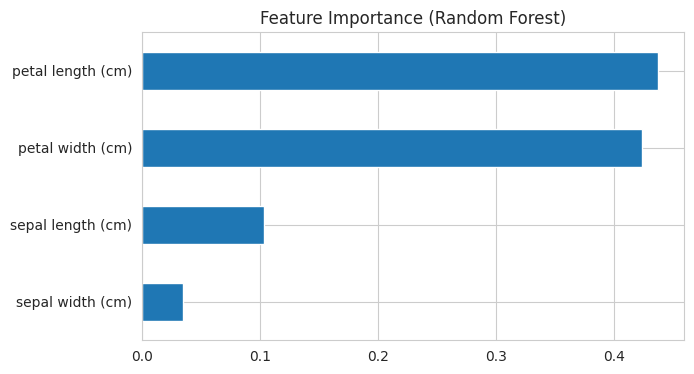

In [23]:
# --- Random Forest Classification & Feature Importance ---
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

rf = RandomForestClassifier(n_estimators=200, max_depth=4, random_state=42)
rf.fit(X_train, y_train)
print(f"Random Forest accuracy: {rf.score(X_test, y_test):.3f}")

importances = pd.Series(rf.feature_importances_, index=iris.feature_names).sort_values(ascending=False)
importances.plot(kind="barh", title="Feature Importance (Random Forest)")
plt.gca().invert_yaxis()
plt.show()


In [24]:
# --- Random Forest Regression + Hyperparameter Tuning ---
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(Xh_train, yh_train)
print(f"R2 (Random Forest Regression) trên Diabetes Dataset: {rf_reg.score(Xh_test, yh_test):.3f}")

# Hyperparameter tuning (RandomizedSearchCV cho nhanh hơn GridSearch)
from sklearn.model_selection import RandomizedSearchCV
param_dist = {"n_estimators": [50, 100, 200], "max_depth": [None, 5, 10, 20],
              "min_samples_split": [2, 5, 10]}
rand_search = RandomizedSearchCV(RandomForestRegressor(random_state=42), param_dist,
                                  n_iter=6, cv=3, random_state=42, n_jobs=-1)
rand_search.fit(Xh_train[:2000], yh_train[:2000])  # lấy subset cho nhanh
print("Best params:", rand_search.best_params_)


R2 (Random Forest Regression) trên Diabetes Dataset: 0.443


Best params: {'n_estimators': 200, 'min_samples_split': 10, 'max_depth': 10}


## 2.8 Ensemble Learning (Học kết hợp)

Kết hợp nhiều mô hình đơn giản thành một mô hình mạnh hơn. Hai chiến lược chính:

- **Bagging** (Bootstrap Aggregating): huấn luyện nhiều mô hình **độc lập, song song** trên các mẫu con của dữ liệu rồi tổng hợp kết quả (VD: Random Forest).
- **Boosting**: huấn luyện các mô hình **tuần tự**, mỗi mô hình sau cố sửa lỗi của mô hình trước (VD: AdaBoost, Gradient Boosting).

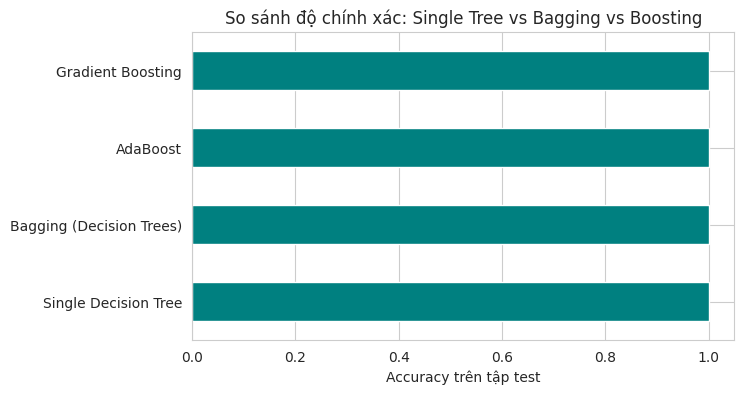

Single Decision Tree        1.0
Bagging (Decision Trees)    1.0
AdaBoost                    1.0
Gradient Boosting           1.0
dtype: float64


In [25]:
# --- So sánh Bagging vs Boosting (AdaBoost) ---
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

models = {
    "Single Decision Tree": DecisionTreeClassifier(max_depth=3, random_state=42),
    "Bagging (Decision Trees)": BaggingClassifier(DecisionTreeClassifier(max_depth=3), n_estimators=50, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=50, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    results[name] = model.score(X_test, y_test)

pd.Series(results).sort_values().plot(kind="barh", color="teal")
plt.title("So sánh độ chính xác: Single Tree vs Bagging vs Boosting")
plt.xlabel("Accuracy trên tập test")
plt.show()
print(pd.Series(results))


---
# 🔍 Module 3: Unsupervised Learning (Học không giám sát)

Ba nhóm chính: **Clustering (phân cụm)**, **Dimensionality Reduction (giảm chiều dữ liệu)**, **Association Rule Mining (khai phá luật kết hợp)**.

## 3.1 Clustering (Phân cụm)

Nhóm các điểm dữ liệu có đặc điểm tương tự vào cùng một cụm. Các nhóm phương pháp chính:

- **Centroid-based**: K-Means, K-Means++, K-Mode, Fuzzy C-Means.
- **Distribution-based**: Gaussian Mixture Models (GMM), Expectation-Maximization.
- **Connectivity-based**: Hierarchical Clustering (Agglomerative/Divisive), Affinity Propagation.
- **Density-based**: DBSCAN, OPTICS.

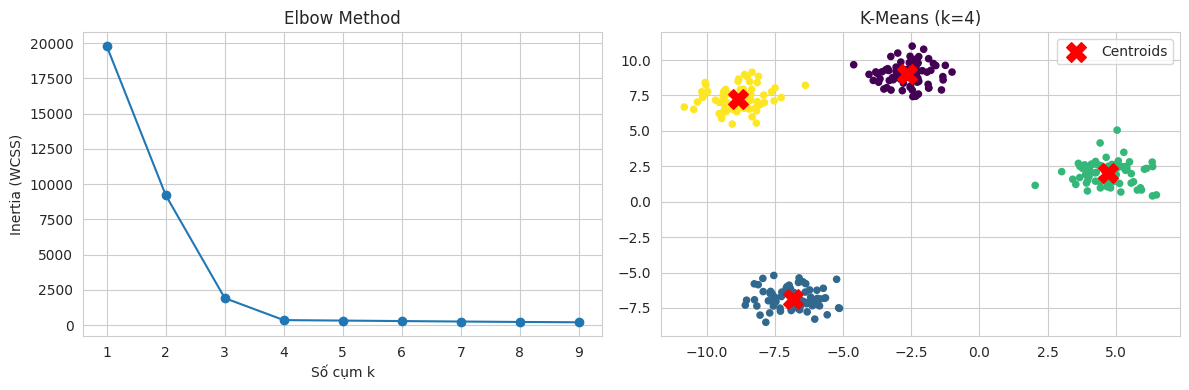

In [26]:
# --- K-Means + Elbow Method để chọn k tối ưu ---
from sklearn.cluster import KMeans

X_blob, y_blob_true = make_blobs(n_samples=300, centers=4, cluster_std=0.8, random_state=42)

inertias = []
K_range = range(1, 10)
for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_blob)
    inertias.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inertias, marker="o")
axes[0].set_xlabel("Số cụm k"); axes[0].set_ylabel("Inertia (WCSS)")
axes[0].set_title("Elbow Method")

km_final = KMeans(n_clusters=4, n_init=10, random_state=42).fit(X_blob)
axes[1].scatter(X_blob[:,0], X_blob[:,1], c=km_final.labels_, cmap="viridis", s=20)
axes[1].scatter(km_final.cluster_centers_[:,0], km_final.cluster_centers_[:,1],
                 c="red", marker="X", s=200, label="Centroids")
axes[1].set_title("K-Means (k=4)"); axes[1].legend()
plt.tight_layout(); plt.show()


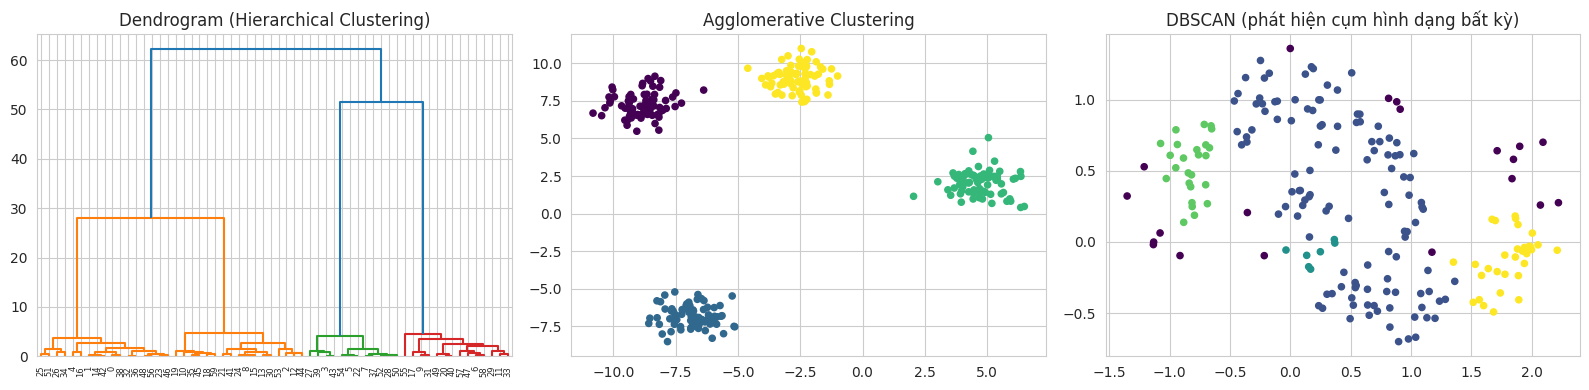

Số cụm DBSCAN tìm được (không cần chỉ định trước k): 4


In [27]:
# --- Hierarchical Clustering (Dendrogram) & DBSCAN ---
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering, DBSCAN

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Dendrogram
Z = linkage(X_blob[:60], method="ward")
dendrogram(Z, ax=axes[0])
axes[0].set_title("Dendrogram (Hierarchical Clustering)")

# Agglomerative Clustering
agg = AgglomerativeClustering(n_clusters=4).fit(X_blob)
axes[1].scatter(X_blob[:,0], X_blob[:,1], c=agg.labels_, cmap="viridis", s=20)
axes[1].set_title("Agglomerative Clustering")

# DBSCAN - trên dữ liệu moons (phi cầu, phù hợp density-based)
dbscan = DBSCAN(eps=0.2, min_samples=5).fit(X_moon)
axes[2].scatter(X_moon[:,0], X_moon[:,1], c=dbscan.labels_, cmap="viridis", s=20)
axes[2].set_title("DBSCAN (phát hiện cụm hình dạng bất kỳ)")

plt.tight_layout(); plt.show()
print("Số cụm DBSCAN tìm được (không cần chỉ định trước k):", len(set(dbscan.labels_)) - (1 if -1 in dbscan.labels_ else 0))


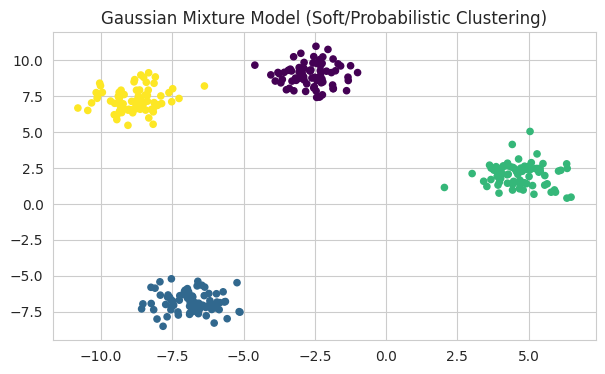

Log-likelihood trung bình: -3.711


In [28]:
# --- Gaussian Mixture Model (Distribution-based clustering) ---
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=4, random_state=42).fit(X_blob)
labels_gmm = gmm.predict(X_blob)

plt.scatter(X_blob[:,0], X_blob[:,1], c=labels_gmm, cmap="viridis", s=20)
plt.title("Gaussian Mixture Model (Soft/Probabilistic Clustering)")
plt.show()
print(f"Log-likelihood trung bình: {gmm.score(X_blob):.3f}")


## 3.2 Dimensionality Reduction (Giảm chiều dữ liệu)

Giảm số lượng đặc trưng trong khi vẫn giữ lại phần lớn thông tin quan trọng — giúp trực quan hóa, giảm nhiễu, tăng tốc huấn luyện.

- **PCA (Principal Component Analysis)**: tìm các trục (thành phần chính) giữ phương sai lớn nhất, phương pháp tuyến tính phổ biến nhất.
- **t-SNE**: kỹ thuật phi tuyến, tốt cho trực quan hóa dữ liệu nhiều chiều (giữ cấu trúc cục bộ).

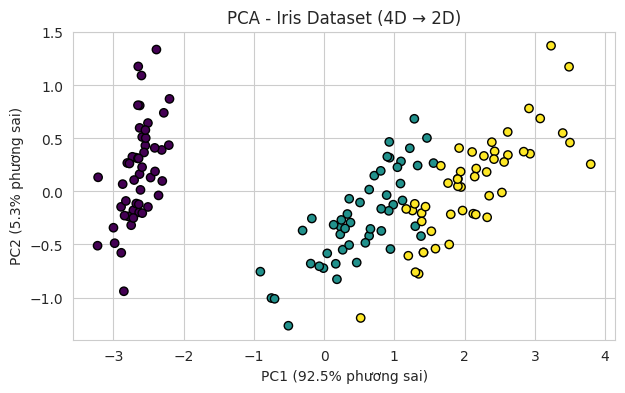

Tổng phương sai giữ lại với 2 thành phần: 0.978


In [29]:
# --- PCA trên Iris (4D -> 2D) ---
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(iris.data)

plt.scatter(X_pca[:,0], X_pca[:,1], c=iris.target, cmap="viridis", edgecolor="k")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% phương sai)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% phương sai)")
plt.title("PCA - Iris Dataset (4D → 2D)")
plt.show()
print("Tổng phương sai giữ lại với 2 thành phần:", pca.explained_variance_ratio_.sum().round(3))


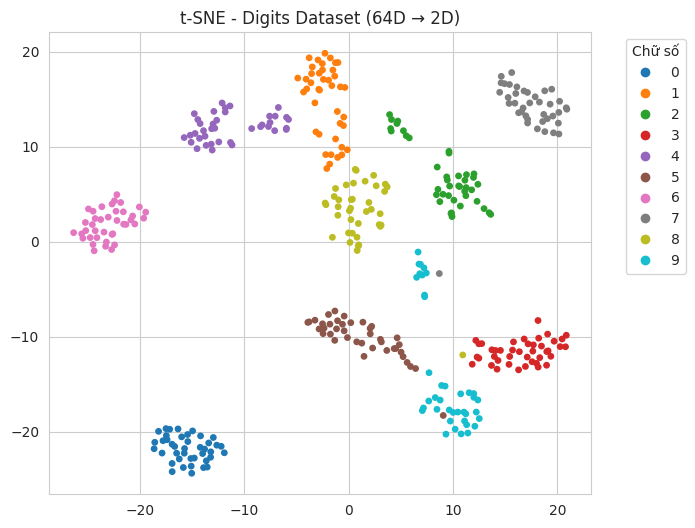

In [30]:
# --- t-SNE trên digits dataset (64 chiều -> 2D) ---
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE

digits = load_digits()
X_tsne = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(digits.data[:400])

plt.figure(figsize=(7,6))
scatter = plt.scatter(X_tsne[:,0], X_tsne[:,1], c=digits.target[:400], cmap="tab10", s=15)
plt.legend(*scatter.legend_elements(), title="Chữ số", bbox_to_anchor=(1.05, 1))
plt.title("t-SNE - Digits Dataset (64D → 2D)")
plt.show()


## 3.3 Association Rule Mining (Khai phá luật kết hợp)

Tìm các mẫu/quy luật xuất hiện đồng thời giữa các item trong dữ liệu giao dịch lớn — ứng dụng kinh điển: **Market Basket Analysis** ("khách mua bánh mì thường mua thêm bơ").

- **Apriori**: sinh tập phổ biến (frequent itemsets) theo cách "sinh và kiểm tra" dựa trên ngưỡng support.
- **FP-Growth**: hiệu quả hơn Apriori nhờ dùng cấu trúc cây FP-Tree, không cần sinh candidate.
- **ECLAT**: dùng biểu diễn vertical (tid-list) và giao các tập để tính support nhanh hơn.

Cần cài thư viện `mlxtend`: `pip install mlxtend`

In [31]:
# --- Apriori & FP-Growth với mlxtend ---
# !pip install mlxtend --quiet
try:
    from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
    from mlxtend.preprocessing import TransactionEncoder

    transactions = [
        ["Sữa", "Bánh mì", "Bơ"],
        ["Bia", "Tã"],
        ["Sữa", "Tã", "Bia", "Trứng"],
        ["Bánh mì", "Sữa", "Tã", "Bia"],
        ["Bánh mì", "Sữa", "Tã", "Trứng"],
    ]
    te = TransactionEncoder()
    te_ary = te.fit(transactions).transform(transactions)
    df_trans = pd.DataFrame(te_ary, columns=te.columns_)

    freq_items = apriori(df_trans, min_support=0.4, use_colnames=True)
    rules = association_rules(freq_items, metric="confidence", min_threshold=0.6)
    print("Tập phổ biến (Apriori):\n", freq_items)
    print("\nLuật kết hợp (support, confidence, lift):")
    print(rules[["antecedents", "consequents", "support", "confidence", "lift"]])

    freq_items_fp = fpgrowth(df_trans, min_support=0.4, use_colnames=True)
    print("\nTập phổ biến (FP-Growth) — kết quả tương đương Apriori nhưng tính nhanh hơn trên dữ liệu lớn:")
    print(freq_items_fp)
except ImportError:
    print("Chưa cài mlxtend. Chạy: pip install mlxtend --break-system-packages")


Tập phổ biến (Apriori):
     support                       itemsets
0       0.6               frozenset({Bia})
1       0.6           frozenset({Bánh mì})
2       0.8               frozenset({Sữa})
3       0.4             frozenset({Trứng})
4       0.8                frozenset({Tã})
5       0.4          frozenset({Bia, Sữa})
6       0.6           frozenset({Bia, Tã})
7       0.6      frozenset({Bánh mì, Sữa})
8       0.4       frozenset({Bánh mì, Tã})
9       0.4        frozenset({Trứng, Sữa})
10      0.6           frozenset({Sữa, Tã})
11      0.4         frozenset({Trứng, Tã})
12      0.4      frozenset({Bia, Sữa, Tã})
13      0.4  frozenset({Bánh mì, Sữa, Tã})
14      0.4    frozenset({Trứng, Sữa, Tã})

Luật kết hợp (support, confidence, lift):
                  antecedents           consequents  support  confidence  \
0            frozenset({Bia})      frozenset({Sữa})      0.4    0.666667   
1            frozenset({Bia})       frozenset({Tã})      0.6    1.000000   
2             fr

In [32]:
# --- ECLAT cài đặt thủ công (minh họa ý tưởng vertical/tid-list) ---
from itertools import combinations

def eclat(transactions, min_support=0.4):
    n = len(transactions)
    items = set(item for t in transactions for item in t)
    # tid-list cho từng item
    tidlists = {item: set(i for i, t in enumerate(transactions) if item in t) for item in items}
    freq_1 = {frozenset([item]): tids for item, tids in tidlists.items() if len(tids)/n >= min_support}

    result = dict(freq_1)
    current = freq_1
    k = 2
    while current:
        candidates = {}
        keys = list(current.keys())
        for i in range(len(keys)):
            for j in range(i+1, len(keys)):
                union_items = keys[i] | keys[j]
                if len(union_items) == k:
                    inter_tids = current[keys[i]] & current[keys[j]]
                    if len(inter_tids)/n >= min_support:
                        candidates[union_items] = inter_tids
        result.update(candidates)
        current = candidates
        k += 1
    return result

freq_eclat = eclat(transactions, min_support=0.4)
print("Tập phổ biến tìm được bằng ECLAT (tự cài đặt):")
for itemset, tids in freq_eclat.items():
    print(f"{set(itemset)} -> support = {len(tids)/len(transactions):.2f}")


Tập phổ biến tìm được bằng ECLAT (tự cài đặt):
{'Bánh mì'} -> support = 0.60
{'Tã'} -> support = 0.80
{'Bia'} -> support = 0.60
{'Sữa'} -> support = 0.80
{'Trứng'} -> support = 0.40
{'Bánh mì', 'Tã'} -> support = 0.40
{'Bánh mì', 'Sữa'} -> support = 0.60
{'Tã', 'Bia'} -> support = 0.60
{'Tã', 'Sữa'} -> support = 0.60
{'Trứng', 'Tã'} -> support = 0.40
{'Bia', 'Sữa'} -> support = 0.40
{'Trứng', 'Sữa'} -> support = 0.40
{'Bánh mì', 'Tã', 'Sữa'} -> support = 0.40
{'Tã', 'Bia', 'Sữa'} -> support = 0.40
{'Trứng', 'Tã', 'Sữa'} -> support = 0.40


---
# 🎮 Module 4: Reinforcement Learning (Học tăng cường)

Agent tương tác với **môi trường (Environment)**, ở mỗi bước nhận **trạng thái (state)**, thực hiện **hành động (action)**, và nhận lại **phần thưởng (reward)**. Mục tiêu: học **chính sách (policy)** tối đa hóa tổng phần thưởng kỳ vọng theo thời gian.

## 4.1 Model-Based Methods

- **Markov Decision Process (MDP)**: khung toán học mô tả bài toán RL bằng bộ `(S, A, P, R, γ)` — tập trạng thái, tập hành động, hàm chuyển trạng thái, hàm thưởng, hệ số chiết khấu.
- **Bellman Equation**: phương trình đệ quy biểu diễn giá trị của một trạng thái dựa trên giá trị các trạng thái kế tiếp: 

$$V(s) = \max_a \Big[ R(s,a) + \gamma \sum_{s'} P(s'|s,a) V(s') \Big]$$

- **Value Iteration**: thuật toán lặp cập nhật giá trị trạng thái đến khi hội tụ, từ đó suy ra chính sách tối ưu.
- **Monte Carlo Tree Search (MCTS)**: tìm kiếm cây quyết định dựa trên việc mô phỏng ngẫu nhiên nhiều lượt chơi (nổi tiếng trong AlphaGo).

Value Iteration hội tụ sau 7 vòng lặp.

Bảng giá trị trạng thái V(s):
[[ 5.5   6.22  7.02  7.91]
 [ 6.22  0.    7.91  8.9 ]
 [ 7.02  7.91  8.9  10.  ]
 [ 7.91  8.9  10.    0.  ]]


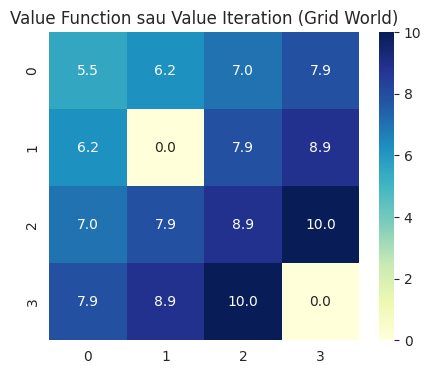

In [33]:
# --- Cài đặt Grid World đơn giản + Value Iteration ---
# Grid 4x4: 0=trống, -1=tường/hố, +10 = đích
grid_size = 4
rewards = np.full((grid_size, grid_size), -0.1)   # mỗi bước đi tốn nhẹ chi phí
rewards[3, 3] = 10     # ô đích
rewards[1, 1] = -5     # ô "bẫy"
terminal_states = {(3,3), (1,1)}

actions = {"up": (-1,0), "down": (1,0), "left": (0,-1), "right": (0,1)}
gamma = 0.9

V = np.zeros((grid_size, grid_size))

def in_bounds(r, c):
    return 0 <= r < grid_size and 0 <= c < grid_size

for iteration in range(100):
    V_new = V.copy()
    for r in range(grid_size):
        for c in range(grid_size):
            if (r, c) in terminal_states:
                continue
            action_values = []
            for a, (dr, dc) in actions.items():
                nr, nc = r+dr, c+dc
                if not in_bounds(nr, nc):
                    nr, nc = r, c  # đâm tường -> đứng yên
                action_values.append(rewards[nr, nc] + gamma * V[nr, nc])
            V_new[r, c] = max(action_values)
    if np.max(np.abs(V_new - V)) < 1e-4:
        break
    V = V_new

print(f"Value Iteration hội tụ sau {iteration+1} vòng lặp.\n")
print("Bảng giá trị trạng thái V(s):")
print(np.round(V, 2))

plt.figure(figsize=(5,4))
sns.heatmap(V, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Value Function sau Value Iteration (Grid World)")
plt.show()


## 4.2 Model-Free Methods

Agent học **trực tiếp từ kinh nghiệm tương tác** với môi trường, không cần biết trước mô hình môi trường (P, R):

- **Q-Learning**: học off-policy, cập nhật giá trị hành động `Q(s,a)` theo hành động tốt nhất ở bước kế tiếp (max), hội tụ về chính sách tối ưu dù đang khám phá ngẫu nhiên.
- **SARSA**: học on-policy, cập nhật `Q(s,a)` dựa trên hành động **thực sự được chọn** ở bước kế tiếp (theo policy hiện tại) — thận trọng hơn Q-Learning.
- **Monte Carlo Methods**: ước lượng giá trị bằng cách lấy trung bình phần thưởng từ nhiều episode đầy đủ.
- **REINFORCE / Actor-Critic / A3C**: các phương pháp Policy Gradient — học trực tiếp chính sách (thường dùng mạng nơ-ron), phù hợp không gian hành động liên tục/phức tạp; Actor-Critic kết hợp ước lượng giá trị (Critic) để giảm phương sai cho Actor.

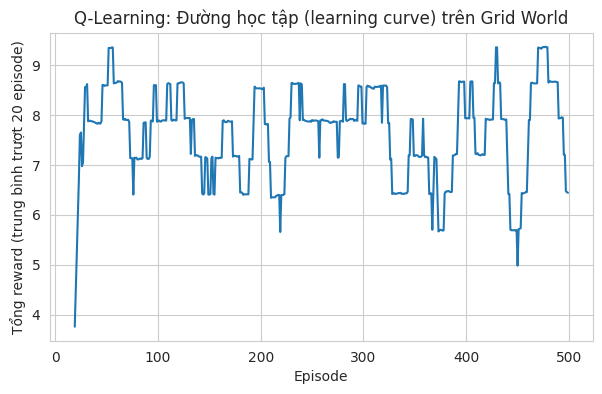

Chính sách tối ưu học được (mỗi ô là hành động tốt nhất):
→ → ↓ ↓
↑ 💀 → ↓
→ ↓ ↓ ↓
→ → → 🏁


In [34]:
# --- Q-Learning cài đặt từ đầu trên Grid World ---
np.random.seed(42)
Q = np.zeros((grid_size, grid_size, len(actions)))
action_list = list(actions.keys())
alpha, gamma_q, epsilon = 0.5, 0.9, 0.2
n_episodes = 500

def step(state, action_idx):
    dr, dc = actions[action_list[action_idx]]
    r, c = state
    nr, nc = r+dr, c+dc
    if not in_bounds(nr, nc):
        nr, nc = r, c
    reward = rewards[nr, nc]
    done = (nr, nc) in terminal_states
    return (nr, nc), reward, done

episode_rewards = []
for ep in range(n_episodes):
    state = (0, 0)
    total_reward = 0
    for t in range(50):
        if np.random.rand() < epsilon:
            a = np.random.randint(len(actions))
        else:
            a = np.argmax(Q[state[0], state[1]])
        next_state, reward, done = step(state, a)
        best_next = np.max(Q[next_state[0], next_state[1]])
        Q[state[0], state[1], a] += alpha * (reward + gamma_q * best_next - Q[state[0], state[1], a])
        state = next_state
        total_reward += reward
        if done:
            break
    episode_rewards.append(total_reward)

plt.plot(pd.Series(episode_rewards).rolling(20).mean())
plt.xlabel("Episode"); plt.ylabel("Tổng reward (trung bình trượt 20 episode)")
plt.title("Q-Learning: Đường học tập (learning curve) trên Grid World")
plt.show()

# Chính sách tối ưu học được
policy_symbols = {0:"↑", 1:"↓", 2:"←", 3:"→"}
best_actions = np.argmax(Q, axis=2)
print("Chính sách tối ưu học được (mỗi ô là hành động tốt nhất):")
for r in range(grid_size):
    print(" ".join(policy_symbols[best_actions[r,c]] if (r,c) not in terminal_states else "🏁" if (r,c)==(3,3) else "💀" for c in range(grid_size)))


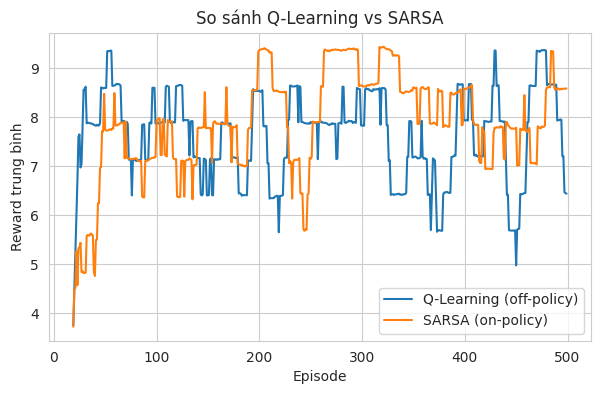

In [35]:
# --- SARSA (on-policy) so sánh với Q-Learning ---
Q_sarsa = np.zeros((grid_size, grid_size, len(actions)))

def choose_action(state, Q_table, eps):
    if np.random.rand() < eps:
        return np.random.randint(len(actions))
    return np.argmax(Q_table[state[0], state[1]])

sarsa_rewards = []
for ep in range(n_episodes):
    state = (0, 0)
    a = choose_action(state, Q_sarsa, epsilon)
    total_reward = 0
    for t in range(50):
        next_state, reward, done = step(state, a)
        next_a = choose_action(next_state, Q_sarsa, epsilon)
        Q_sarsa[state[0], state[1], a] += alpha * (
            reward + gamma_q * Q_sarsa[next_state[0], next_state[1], next_a] - Q_sarsa[state[0], state[1], a]
        )
        state, a = next_state, next_a
        total_reward += reward
        if done:
            break
    sarsa_rewards.append(total_reward)

plt.plot(pd.Series(episode_rewards).rolling(20).mean(), label="Q-Learning (off-policy)")
plt.plot(pd.Series(sarsa_rewards).rolling(20).mean(), label="SARSA (on-policy)")
plt.xlabel("Episode"); plt.ylabel("Reward trung bình")
plt.title("So sánh Q-Learning vs SARSA")
plt.legend(); plt.show()


> **Ghi chú:** Các thuật toán nâng cao hơn như *REINFORCE*, *Actor-Critic*, *A3C* thường cần mạng nơ-ron (PyTorch/TensorFlow) và môi trường phức tạp hơn (VD: OpenAI Gym / Gymnasium). Ý tưởng cốt lõi:
> - **REINFORCE**: cập nhật trực tiếp tham số chính sách theo hướng gradient của phần thưởng kỳ vọng (Policy Gradient thuần).
> - **Actor-Critic**: Actor chọn hành động, Critic ước lượng giá trị trạng thái để "chấm điểm" hành động đó, giúp giảm phương sai khi huấn luyện so với REINFORCE thuần.
> - **A3C (Asynchronous Advantage Actor-Critic)**: chạy nhiều agent song song (bất đồng bộ) trên nhiều bản sao môi trường để tăng tốc và ổn định huấn luyện.
>
> Đây cũng là nền tảng gần với bài toán **điều khiển tín hiệu giao thông thông minh bằng RL/PPO/MAPPO** — rất phù hợp để bạn liên hệ với đề tài khóa luận của mình.

---
# 🌓 Module 5: Semi-Supervised Learning

Kết hợp một lượng nhỏ dữ liệu có nhãn với lượng lớn dữ liệu không nhãn để huấn luyện mô hình — hữu ích khi việc gán nhãn tốn kém.

- **Self-Training**: huấn luyện mô hình ban đầu trên dữ liệu có nhãn, dùng nó để "tự gán nhãn" (pseudo-label) cho dữ liệu chưa có nhãn với độ tin cậy cao, rồi thêm vào tập huấn luyện và lặp lại.
- **Few-shot Learning**: học từ **rất ít** ví dụ cho mỗi lớp (thường dùng trong Meta-Learning, phổ biến trong Computer Vision/NLP hiện đại).

In [36]:
# --- Self-Training Classifier (sklearn) ---
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.svm import SVC as SVC_st

X_ss, y_ss = make_classification(n_samples=300, n_features=2, n_redundant=0,
                                  n_informative=2, n_clusters_per_class=1, random_state=1)
y_ss_masked = y_ss.copy()
rng = np.random.RandomState(42)
unlabeled_idx = rng.choice(len(y_ss), size=int(0.8*len(y_ss)), replace=False)
y_ss_masked[unlabeled_idx] = -1  # -1 nghĩa là "không nhãn" theo quy ước sklearn

base_model = SVC_st(probability=True, kernel="rbf", gamma="scale")
self_training = SelfTrainingClassifier(base_model, threshold=0.8)
self_training.fit(X_ss, y_ss_masked)

acc_semi = self_training.score(X_ss, y_ss)
print(f"Chỉ 20% dữ liệu có nhãn ban đầu, sau Self-Training: accuracy toàn tập = {acc_semi:.3f}")

# So sánh với việc chỉ dùng 20% dữ liệu có nhãn (Supervised thuần)
labeled_mask = y_ss_masked != -1
base_only = SVC_st(probability=True, kernel="rbf", gamma="scale").fit(X_ss[labeled_mask], y_ss[labeled_mask])
print(f"Chỉ huấn luyện trên 20% dữ liệu có nhãn (không self-training): accuracy = {base_only.score(X_ss, y_ss):.3f}")


Chỉ 20% dữ liệu có nhãn ban đầu, sau Self-Training: accuracy toàn tập = 0.857
Chỉ huấn luyện trên 20% dữ liệu có nhãn (không self-training): accuracy = 0.863


> **Self-Supervised Learning** (không có bài trực tiếp trong mục thực hành do cần deep learning): mô hình tự sinh "nhãn giả" từ chính cấu trúc dữ liệu — ví dụ: che một phần ảnh và yêu cầu mô hình dự đoán phần bị che (masked image modeling), hoặc dự đoán từ tiếp theo trong câu (như pretraining của BERT/GPT). Đây là nền tảng huấn luyện các mô hình nền tảng (foundation models) quy mô lớn hiện nay.

---
# 📈 Module 6: Forecasting Models (Dự báo chuỗi thời gian)

Phân tích dữ liệu quá khứ để dự đoán xu hướng tương lai (doanh số, nhu cầu, giá cổ phiếu...).

- **ARIMA (AutoRegressive Integrated Moving Average)**: kết hợp thành phần tự hồi quy (AR), sai phân để khử xu hướng (I), và trung bình trượt của phần dư (MA).
- **SARIMA**: mở rộng ARIMA thêm thành phần **mùa vụ (Seasonal)**.
- **Exponential Smoothing (Holt-Winters)**: dự báo dựa trên trung bình có trọng số giảm dần theo thời gian, có thể mở hình hóa cả xu hướng và mùa vụ.

Cần cài `statsmodels`: `pip install statsmodels`

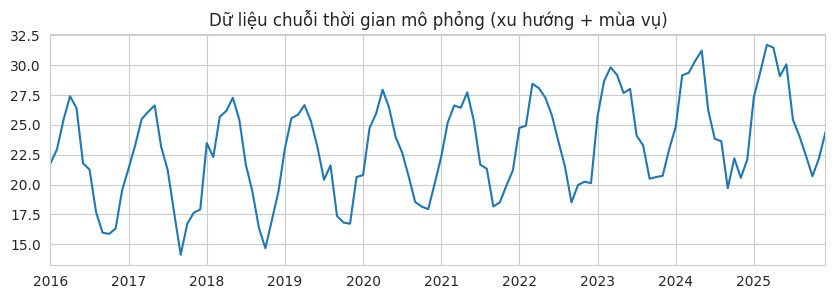

In [37]:
# --- Tạo dữ liệu chuỗi thời gian có xu hướng + mùa vụ ---
np.random.seed(0)
n_points = 120
t = np.arange(n_points)
trend = 0.05 * t
seasonal = 5 * np.sin(2 * np.pi * t / 12)
noise = np.random.normal(0, 1, n_points)
ts_values = 20 + trend + seasonal + noise
dates = pd.date_range("2016-01-01", periods=n_points, freq="MS")
ts = pd.Series(ts_values, index=dates)

ts.plot(figsize=(10,3), title="Dữ liệu chuỗi thời gian mô phỏng (xu hướng + mùa vụ)")
plt.show()


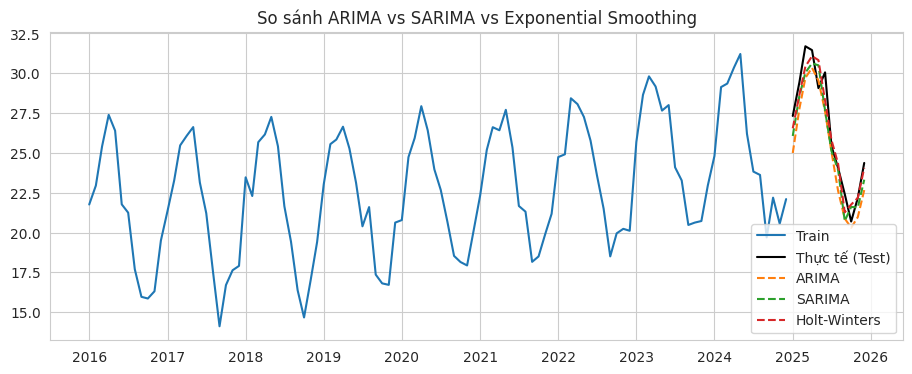

ARIMA - MAE trên 12 tháng test: 1.388
SARIMA - MAE trên 12 tháng test: 1.092
Holt-Winters - MAE trên 12 tháng test: 0.827


In [38]:
# --- ARIMA & SARIMA & Exponential Smoothing (Holt-Winters) ---
try:
    from statsmodels.tsa.arima.model import ARIMA
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    from statsmodels.tsa.holtwinters import ExponentialSmoothing

    train, test = ts[:-12], ts[-12:]

    # ARIMA (p,d,q)
    arima_model = ARIMA(train, order=(2,1,2)).fit()
    arima_fc = arima_model.forecast(steps=12)

    # SARIMA (p,d,q)(P,D,Q,s) - s=12 tháng
    sarima_model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12)).fit(disp=False)
    sarima_fc = sarima_model.forecast(steps=12)

    # Holt-Winters Exponential Smoothing
    hw_model = ExponentialSmoothing(train, trend="add", seasonal="add", seasonal_periods=12).fit()
    hw_fc = hw_model.forecast(12)

    plt.figure(figsize=(11,4))
    plt.plot(train.index, train, label="Train")
    plt.plot(test.index, test, label="Thực tế (Test)", color="black")
    plt.plot(test.index, arima_fc, "--", label="ARIMA")
    plt.plot(test.index, sarima_fc, "--", label="SARIMA")
    plt.plot(test.index, hw_fc, "--", label="Holt-Winters")
    plt.legend(); plt.title("So sánh ARIMA vs SARIMA vs Exponential Smoothing")
    plt.show()

    from sklearn.metrics import mean_absolute_error
    for name, fc in [("ARIMA", arima_fc), ("SARIMA", sarima_fc), ("Holt-Winters", hw_fc)]:
        print(f"{name} - MAE trên 12 tháng test: {mean_absolute_error(test, fc):.3f}")
except ImportError:
    print("Chưa cài statsmodels. Chạy: pip install statsmodels --break-system-packages")


---
# 🚀 Module 7: Deployment of ML Models (Triển khai mô hình)

Sau khi có mô hình tốt, cần **đóng gói & triển khai** để ứng dụng thực tế có thể sử dụng.

## 7.1 Lưu & tải mô hình

In [39]:
import joblib

# Huấn luyện và lưu mô hình
final_model = RandomForestClassifier(n_estimators=100, random_state=42).fit(iris.data, iris.target)
joblib.dump(final_model, "iris_model.pkl")
print("Đã lưu mô hình vào iris_model.pkl")

# Tải lại và dự đoán thử
loaded_model = joblib.load("iris_model.pkl")
sample = iris.data[[0, 50, 100]]
print("Dự đoán mẫu thử:", loaded_model.predict(sample), "-> nhãn thực:", iris.target[[0,50,100]])


Đã lưu mô hình vào iris_model.pkl
Dự đoán mẫu thử: [0 1 2] -> nhãn thực: [0 1 2]


## 7.2 Triển khai với Flask (REST API)

```python
# app.py
from flask import Flask, request, jsonify
import joblib
import numpy as np

app = Flask(__name__)
model = joblib.load("iris_model.pkl")

@app.route("/predict", methods=["POST"])
def predict():
    data = request.get_json()
    X = np.array(data["features"]).reshape(1, -1)
    pred = model.predict(X)[0]
    return jsonify({"prediction": int(pred)})

if __name__ == "__main__":
    app.run(debug=True, port=5000)
```

Gọi thử: `curl -X POST -H "Content-Type: application/json" -d '{"features":[5.1,3.5,1.4,0.2]}' http://localhost:5000/predict`

## 7.3 Triển khai với FastAPI (nhanh hơn, có validation tự động)

```python
# main.py
from fastapi import FastAPI
from pydantic import BaseModel
import joblib
import numpy as np

app = FastAPI()
model = joblib.load("iris_model.pkl")

class InputData(BaseModel):
    features: list[float]

@app.post("/predict")
def predict(data: InputData):
    X = np.array(data.features).reshape(1, -1)
    return {"prediction": int(model.predict(X)[0])}

# Chạy: uvicorn main:app --reload
```

## 7.4 Triển khai với Streamlit (dashboard tương tác nhanh)

```python
# streamlit_app.py
import streamlit as st
import joblib
import numpy as np

model = joblib.load("iris_model.pkl")
st.title("Dự đoán loài hoa Iris")

sl = st.slider("Sepal length", 4.0, 8.0, 5.1)
sw = st.slider("Sepal width", 2.0, 4.5, 3.5)
pl = st.slider("Petal length", 1.0, 7.0, 1.4)
pw = st.slider("Petal width", 0.1, 2.5, 0.2)

if st.button("Dự đoán"):
    pred = model.predict(np.array([[sl, sw, pl, pw]]))[0]
    st.success(f"Kết quả dự đoán: lớp {pred}")

# Chạy: streamlit run streamlit_app.py
```

## 7.5 Prototype nhanh với Gradio

```python
import gradio as gr
import joblib
import numpy as np

model = joblib.load("iris_model.pkl")

def predict(sl, sw, pl, pw):
    return int(model.predict(np.array([[sl, sw, pl, pw]]))[0])

demo = gr.Interface(fn=predict,
    inputs=[gr.Slider(4,8), gr.Slider(2,4.5), gr.Slider(1,7), gr.Slider(0.1,2.5)],
    outputs="label")
demo.launch()
```

## 7.6 MLOps — Vận hành mô hình lâu dài

- **CI/CD cho ML**: tự động kiểm thử, huấn luyện lại, và triển khai mô hình mỗi khi có code/dữ liệu mới (GitHub Actions, Jenkins...).
- **Model Monitoring**: theo dõi độ trôi dữ liệu (**data drift**) và độ trôi mô hình (**model drift**) theo thời gian, đo lại hiệu năng trên dữ liệu thực tế.
- **Versioning**: quản lý phiên bản dữ liệu & mô hình (DVC, MLflow) để có thể tái lập (reproducibility) và rollback khi cần.
- **End-to-End MLOps Pipeline**: kết hợp toàn bộ — thu thập dữ liệu → huấn luyện → kiểm thử → triển khai → giám sát — thành một quy trình tự động khép kín.

---
# ✅ Tổng kết & Tài nguyên tham khảo

Bạn vừa đi qua toàn bộ lộ trình Machine Learning theo cấu trúc GeeksforGeeks:

- **Module 1 – Pipeline:** Data Preprocessing, EDA, Model Evaluation
- **Module 2 – Supervised Learning:** Linear/Logistic Regression, Decision Tree, SVM, KNN, Naive Bayes, Random Forest, Ensemble Learning
- **Module 3 – Unsupervised Learning:** Clustering (K-Means, Hierarchical, DBSCAN, GMM), Dimensionality Reduction (PCA, t-SNE), Association Rule Mining (Apriori, FP-Growth, ECLAT)
- **Module 4 – Reinforcement Learning:** MDP, Bellman Equation, Value Iteration, Q-Learning, SARSA
- **Module 5 – Semi-Supervised Learning:** Self-Training
- **Module 6 – Forecasting:** ARIMA, SARIMA, Holt-Winters
- **Module 7 – Deployment:** Flask, FastAPI, Streamlit, Gradio, MLOps

## 🔗 Bước tiếp theo
- Thực hành thêm với **100+ Machine Learning Projects**: https://www.geeksforgeeks.org/machine-learning/machine-learning-projects/
- Ôn tập phỏng vấn: **ML Interview Questions**: https://www.geeksforgeeks.org/machine-learning/machine-learning-interview-questions/
- Học tiếp **Deep Learning**: https://www.geeksforgeeks.org/deep-learning/deep-learning-tutorial/
- Toán nền tảng cho ML: **Math for Machine Learning**: https://www.geeksforgeeks.org/machine-learning/machine-learning-mathematics/

## 💡 Gợi ý liên hệ với khóa luận tốt nghiệp
Phần **Module 4 (Reinforcement Learning)** trong notebook này — đặc biệt là MDP, Q-Learning và ý tưởng Actor-Critic — chính là nền tảng lý thuyết cho hệ thống **điều khiển tín hiệu giao thông thông minh bằng RL/PPO/MAPPO** mà bạn đang phát triển. Bạn có thể mở rộng Grid World ở trên thành mô phỏng giao lộ (traffic intersection) với state = mật độ xe theo hướng, action = pha đèn tín hiệu, reward = giảm thời gian chờ trung bình.
